In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval
from astropy.convolution import convolve

from astroquery.mast import Observations

from photutils.background import Background2D, MedianBackground
from photutils.segmentation import (
    detect_sources,
    deblend_sources,
    SourceCatalog,
    make_2dgaussian_kernel,
)


# Project directories
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")

DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)


# Query CEERS JWST/NIRCam F200W observations
obs = Observations.query_criteria(
    obs_collection="JWST",
    proposal_id="1345",
    instrument_name="NIRCAM/IMAGE",
)

f200w_obs = obs[
    [str(f).upper() == "F200W" for f in obs["filters"]]
]

# Use one public F200W observation
selected_obs = f200w_obs[0]

data_uri = str(selected_obs["dataURL"])
filename = data_uri.split("/")[-1]

IMAGE_FILE = DATA_DIR / filename


# Download only when the file is not already present
if not IMAGE_FILE.exists():
    Observations.download_file(
        data_uri,
        local_path=str(IMAGE_FILE),
    )

print("Observation:", selected_obs["obs_id"])
print("Image:", IMAGE_FILE)

Observation: jw01345-o071_t047_nircam_clear-f200w
Image: data\jw01345-o071_t047_nircam_clear-f200w_i2d.fits


Set DATE-AVG to '2022-12-22T06:17:19.210' from MJD-AVG.
Set DATE-END to '2022-12-22T06:44:09.762' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.899270 from OBSGEO-[XYZ].
Set OBSGEO-H to 1678146965.955 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


4396 9897
Full image shape: (4396, 9897)
Working image shape: (2150, 2150)


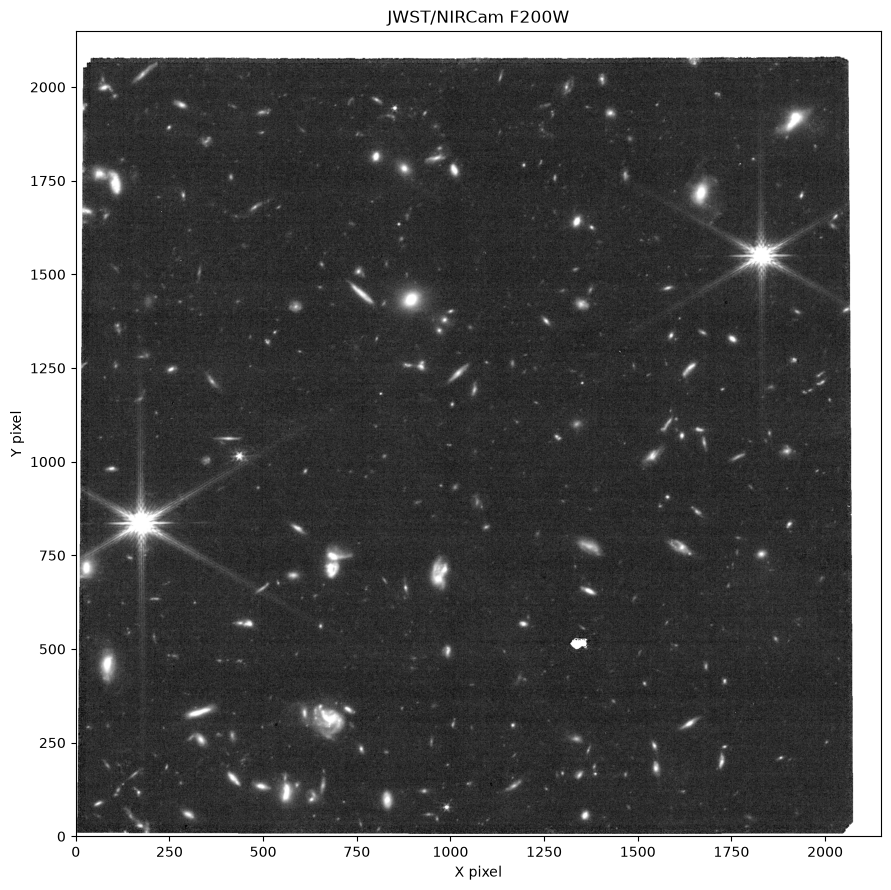

In [3]:
# Load the JWST science image and uncertainty map

with fits.open(IMAGE_FILE) as hdul:
    full_image = hdul["SCI"].data.astype(float)
    full_error = hdul["ERR"].data.astype(float)
    full_wcs = WCS(hdul["SCI"].header).celestial


# Create a cutout for faster analysis
ny, nx = full_image.shape
print(ny, nx)
position = (0, 0)
cutout_size = (4300, 4300)

image_cutout = Cutout2D(
    full_image,
    position=position,
    size=cutout_size,
    wcs=full_wcs,
)

error_cutout = Cutout2D(
    full_error,
    position=position,
    size=cutout_size,
)

image = image_cutout.data
error = error_cutout.data
wcs = image_cutout.wcs

print("Full image shape:", full_image.shape)
print("Working image shape:", image.shape)


# Display the science image
norm = ImageNormalize(
    image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

plt.figure(figsize=(9, 9))
plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    norm=norm,
)

plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("JWST/NIRCam F200W")
plt.tight_layout()
plt.show()

Median background: 0.14183774590492249
Median background RMS: 0.0056406348321248224


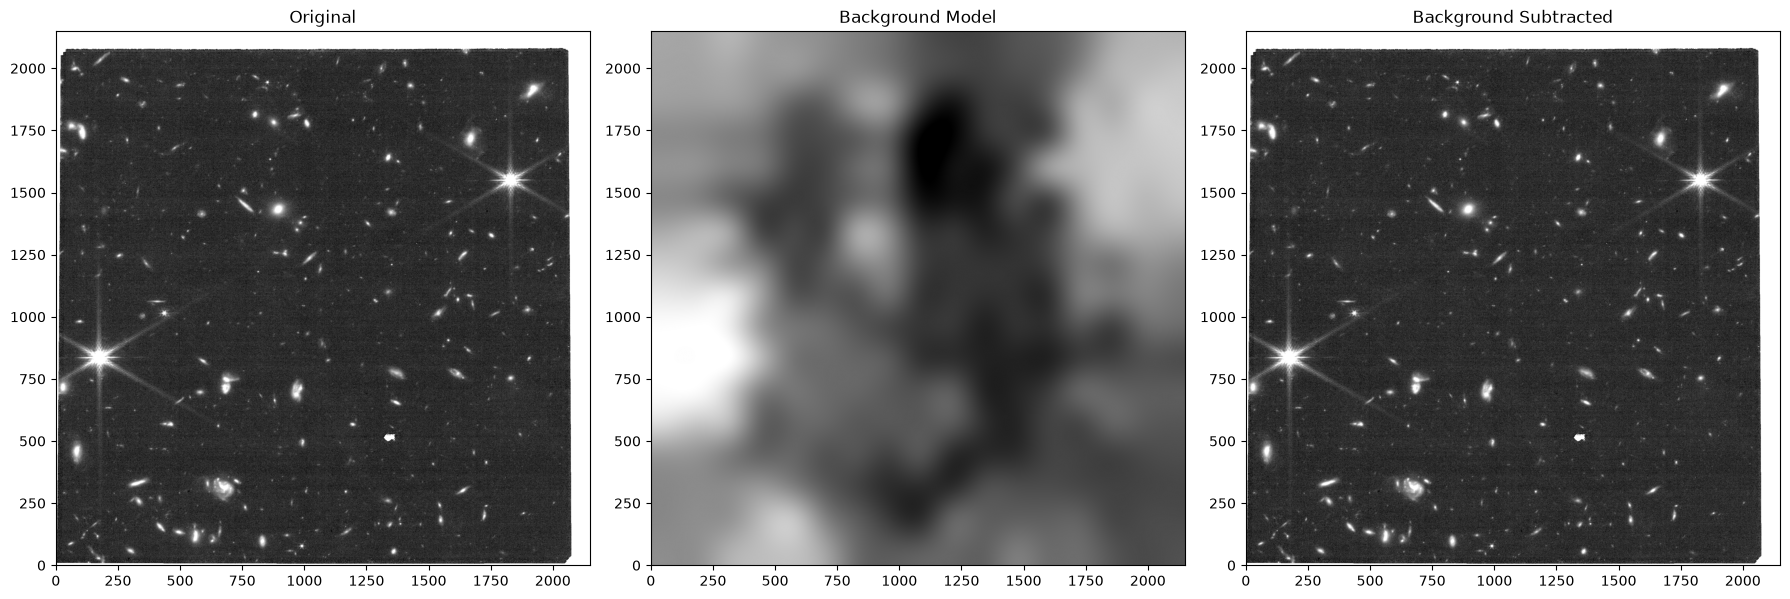

Median background: 0.14183774590492249
Median background RMS: 0.0056406348321248224


In [4]:
# Mask invalid pixels
mask = ~np.isfinite(image)


background = Background2D(
    image,
    box_size=(128, 128),
    filter_size=(3, 3),
    mask=mask,
    bkg_estimator=MedianBackground(),
)

data_sub = image - background.background

print("Median background:", background.background_median)
print("Median background RMS:", background.background_rms_median)


# Display image, background model, and background-subtracted image
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(
    image,
    origin="lower",
    cmap="gray",
    norm=ImageNormalize(
        image,
        interval=PercentileInterval(99.5),
        stretch=AsinhStretch(),
    ),
)
axes[0].set_title("Original")

axes[1].imshow(
    background.background,
    origin="lower",
    cmap="gray",
)
axes[1].set_title("Background Model")

axes[2].imshow(
    data_sub,
    origin="lower",
    cmap="gray",
    norm=ImageNormalize(
        data_sub,
        interval=PercentileInterval(99.5),
        stretch=AsinhStretch(),
    ),
)
axes[2].set_title("Background Subtracted")

plt.tight_layout()
plt.show()

print("Median background:", background.background_median)
print("Median background RMS:", background.background_rms_median)

Detected segments: 979


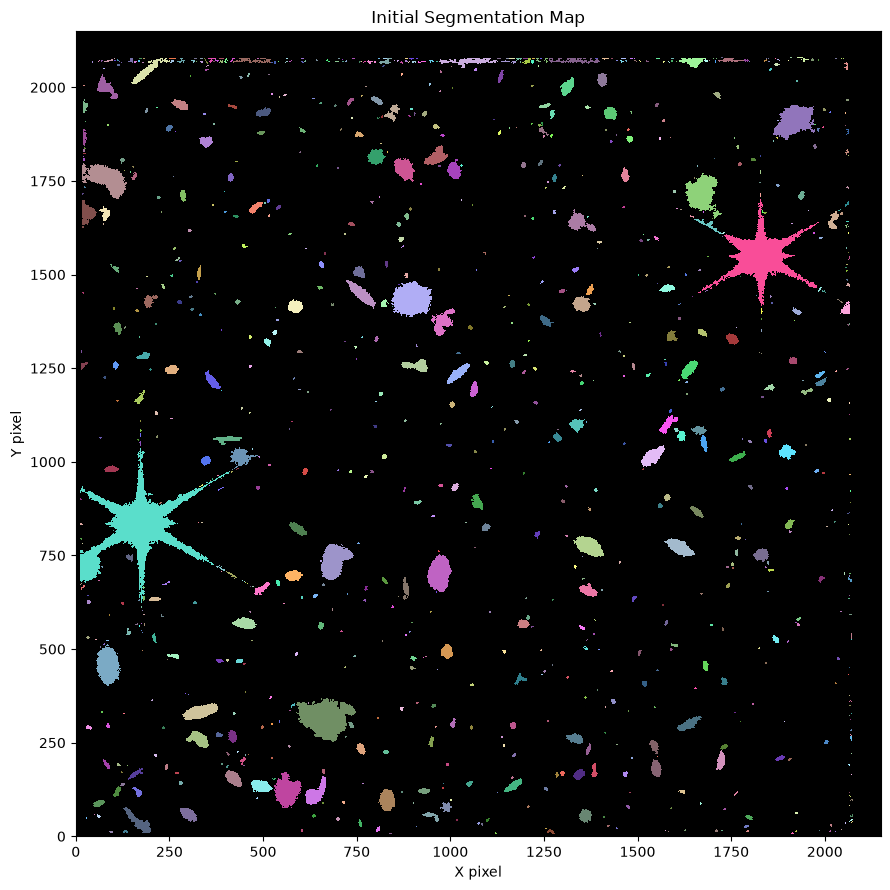

In [5]:
# Smooth the image to improve detection of faint sources
kernel = make_2dgaussian_kernel(
    fwhm=3.0,
    size=9,
)

convolved = convolve(
    data_sub,
    kernel,
    mask=mask,
)


# Define a spatially varying 1.5-sigma detection threshold
threshold = 1.5 * background.background_rms


# Detect connected source regions
segmentation = detect_sources(
    convolved,
    threshold,
    n_pixels=10,
    mask=mask,
)

print("Detected segments:", segmentation.nlabels)


# Display the segmentation map
plt.figure(figsize=(9, 9))
plt.imshow(
    segmentation.data,
    origin="lower",
    cmap=segmentation.cmap,
    interpolation="nearest",
)

plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("Initial Segmentation Map")
plt.tight_layout()
plt.show()

Deblending:   0%|          | 0/690 [00:00<?, ?it/s]

Before deblending: 979
After deblending: 1183


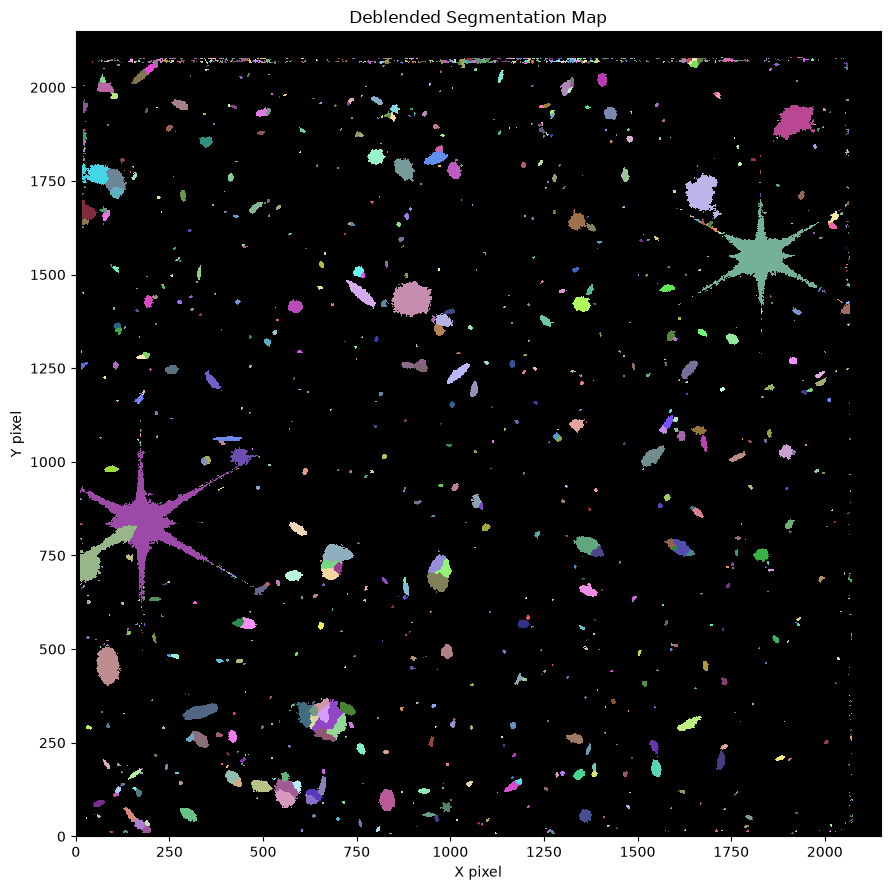

In [6]:
# Separate overlapping sources

segmentation_deblended = deblend_sources(
    convolved,
    segmentation,
    npixels=10,
    nlevels=32,
    contrast=0.02,
    progress_bar=True,
)

print("Before deblending:", segmentation.nlabels)
print("After deblending:", segmentation_deblended.nlabels)


plt.figure(figsize=(9, 9))
plt.imshow(
    segmentation_deblended.data,
    origin="lower",
    cmap=segmentation_deblended.cmap,
    interpolation="nearest",
)

plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("Deblended Segmentation Map")
plt.tight_layout()
plt.show()

In [7]:
# Measure photometric and morphological source properties

catalog = SourceCatalog(
    data_sub,
    segmentation_deblended,
    error=error,
    convolved_data=convolved,
    wcs=wcs,
)

columns = [
    "label",
    "xcentroid",
    "ycentroid",
    "area",
    "segment_flux",
    "segment_fluxerr",
    "ellipticity",
    "elongation",
]

source_table = catalog.to_table(columns=columns)

source_table[:10]

label,x_centroid,y_centroid,area,segment_flux,segment_flux_err,ellipticity,elongation
,,,pix2,,,,
int32,float64,float64,float64,float64,float64,float64,float64
1,1121.621240646473,9.06596276408876,16.0,0.2429001835447658,0.11370036541205789,0.5143361159590121,2.059037191893817
2,1582.298990059703,10.932796635271337,13.0,0.23119272022642176,0.05859543145173427,0.7176584445348467,3.5418094879888145
3,840.7799415061701,8.454776537730979,14.0,0.30574366723106494,0.05551441671307038,0.6656473531687953,2.9908541459964635
4,1913.3519546223645,8.701942488226535,16.0,0.1933752717086257,0.05200463543719553,0.5825350226843243,2.3954105238481533
5,93.99992355030972,12.256617208696921,50.0,0.7287773263283861,0.09917183198230199,0.39160516955294433,1.6436694560096579
6,131.93417925400226,12.479507007730408,91.0,3.6152228878264876,0.1713404445019149,0.33651041353685707,1.5071826602896508
7,603.6100796470063,14.890035695479583,41.0,0.6648817843836481,0.0930219748729773,0.4011374035839391,1.6698321217330596
8,808.1428871754191,18.89795491170136,122.0,2.905364582471279,0.14282951559557513,0.42668695005814583,1.7442477545233284


In [8]:
# Convert source centroids from pixels to sky coordinates

skycoord = wcs.pixel_to_world(
    np.asarray(source_table["xcentroid"]),
    np.asarray(source_table["ycentroid"]),
)

source_table["ra"] = skycoord.ra.deg
source_table["dec"] = skycoord.dec.deg


# Calculate a simple source S/N estimate
flux = np.asarray(source_table["segment_flux"])
fluxerr = np.asarray(source_table["segment_fluxerr"])

source_table["snr"] = flux / fluxerr


# Reorder the final catalog
final_columns = [
    "label",
    "ra",
    "dec",
    "xcentroid",
    "ycentroid",
    "segment_flux",
    "segment_fluxerr",
    "snr",
    "area",
    "ellipticity",
    "elongation",
]

final_catalog = source_table[final_columns]

final_catalog[:10]

label,ra,dec,x_centroid,y_centroid,segment_flux,segment_flux_err,snr,area,ellipticity,elongation
,,,,,,,,pix2,,
int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,214.88836543060845,52.77661695185717,1121.621240646473,9.06596276408876,0.2429001835447658,0.11370036541205789,2.136318407284611,16.0,0.5143361159590121,2.059037191893817
2,214.8840778810768,52.77357661566309,1582.298990059703,10.932796635271337,0.23119272022642176,0.05859543145173427,3.945575866556386,13.0,0.7176584445348467,3.5418094879888145
3,214.89097375953622,52.77847329757647,840.7799415061701,8.454776537730979,0.30574366723106494,0.05551441671307038,5.507464282860425,14.0,0.6656473531687953,2.9908541459964635
4,214.88103623173322,52.77137165299982,1913.3519546223645,8.701942488226535,0.1933752717086257,0.05200463543719553,3.718423753631719,16.0,0.5825350226843243,2.3954105238481533
5,214.8978511880151,52.783439609879466,93.99992355030972,12.256617208696921,0.7287773263283861,0.09917183198230199,7.348632285611526,50.0,0.39160516955294433,1.6436694560096579
6,214.8974972424292,52.783189676768714,131.93417925400226,12.479507007730408,3.6152228878264876,0.1713404445019149,21.099646953385157,91.0,0.33651041353685707,1.5071826602896508
7,214.89310056043527,52.78007988890368,603.6100796470063,14.890035695479583,0.6648817843836481,0.0930219748729773,7.147577605093342,41.0,0.4011374035839391,1.6698321217330596
8,214.89116178929555,52.77874794335263,808.1428871754191,18.89795491170136,2.905364582471279,0.14282951559557513,20.341485934167007,122.0,0.42668695005814583,1.7442477545233284


In [9]:
# Export the catalog

CATALOG_FILE = RESULTS_DIR / "ceers_f200w_source_catalog.csv"

final_catalog.write(
    CATALOG_FILE,
    format="ascii.csv",
    overwrite=True,
)

print("Sources:", len(final_catalog))
print("Catalog:", CATALOG_FILE)

Sources: 1183
Catalog: results\ceers_f200w_source_catalog.csv


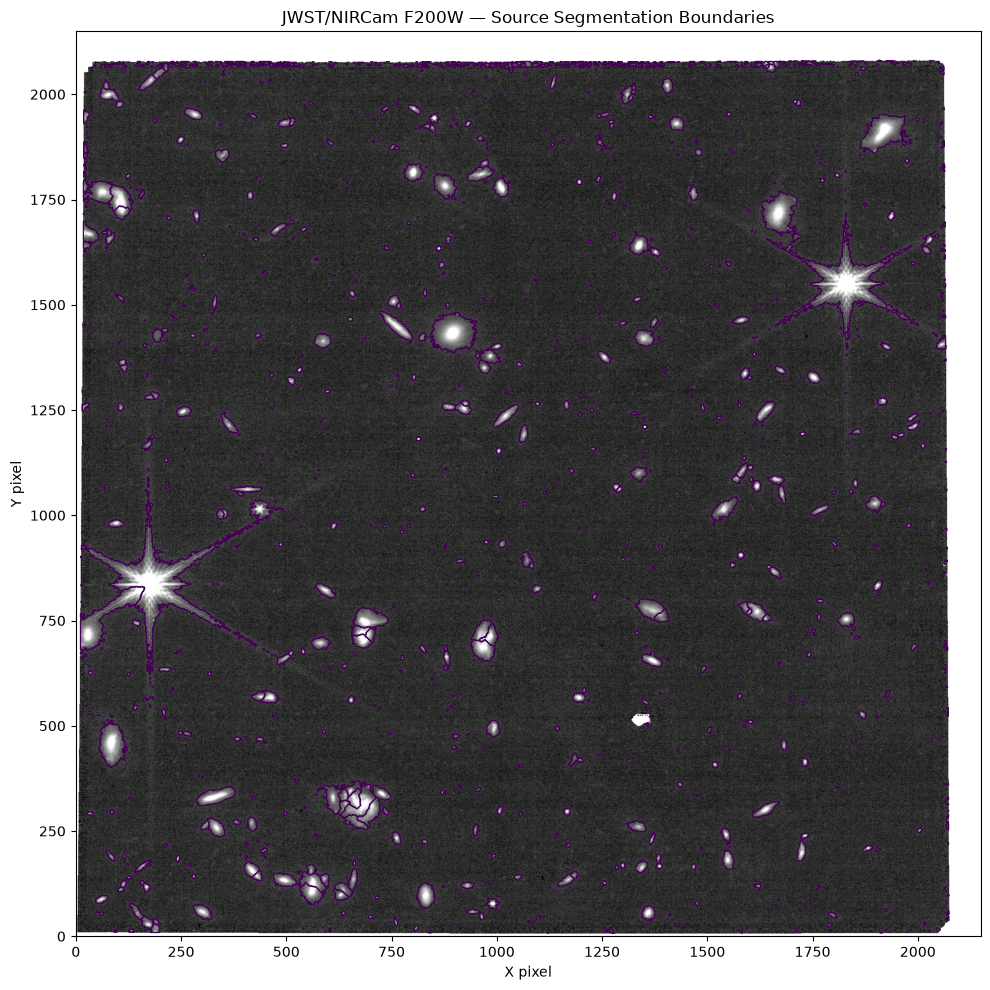

In [10]:
# Create source boundaries from the segmentation map

seg = segmentation_deblended.data

boundary = (
    (seg != np.roll(seg, 1, axis=0)) |
    (seg != np.roll(seg, -1, axis=0)) |
    (seg != np.roll(seg, 1, axis=1)) |
    (seg != np.roll(seg, -1, axis=1))
)

boundary &= seg > 0


# Display source boundaries

norm = ImageNormalize(
    image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

plt.figure(figsize=(10, 10))

plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    norm=norm,
)

plt.contour(
    boundary,
    levels=[0.5],
    linewidths=0.6,
)

plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("JWST/NIRCam F200W — Source Segmentation Boundaries")

plt.tight_layout()
plt.show()